# Actividad 3: comparativa de planificadores

Este notebook reproduce el trabajo experimental usado en el informe. La idea es dejar trazable el proceso completo: qué dominio PDDL se usa, qué problemas se seleccionan, qué configuraciones se ejecutan y cómo se obtienen la tabla de resultados y la gráfica.

## 1. Preparación del entorno

Se añaden las dependencias locales instaladas para la actividad. En particular se usan `pyperplan`, `up-fast-downward`, `pandas` y `matplotlib`.

In [1]:
from pathlib import Path
import json
import os
import re
import subprocess
import sys
import time

ROOT = Path.cwd()
DEPS = ROOT / ".codex_deps"
if str(DEPS) not in sys.path:
    sys.path.insert(0, str(DEPS))

os.environ["PYTHONPATH"] = str(DEPS)
os.environ["MPLCONFIGDIR"] = str(ROOT / ".mplconfig")

import pandas as pd
import matplotlib.pyplot as plt

print(f"Carpeta de trabajo: {ROOT}")
print(f"Dependencias locales: {DEPS.exists()}")

Carpeta de trabajo: /Users/jhonep/Documents/Actividad 3
Dependencias locales: True


## 2. Dominio PDDL elegido

El dominio seleccionado es **Blocks World**. Se utiliza porque es un dominio clásico de STRIPS/PDDL y permite observar con claridad cómo cambia el rendimiento cuando aumenta el número de bloques.

En el archivo `domain.pddl` se comprueba que el dominio declara `:strips` y `:typing`, por lo que encaja con planificación clásica proposicional y tipada.

In [2]:
DOMAIN = ROOT / "pddl" / "blocks" / "domain.pddl"
domain_text = DOMAIN.read_text()

requirements = re.search(r"\(:requirements\s+([^)]*)\)", domain_text, re.I)
predicates = re.search(r"\(:predicates(.*?)\)\s*\(:action", domain_text, re.S | re.I)

print("Requisitos del dominio:", requirements.group(1).strip() if requirements else "No encontrados")
print("\nPredicados principales:")
if predicates:
    for line in predicates.group(1).splitlines():
        line = line.strip()
        if line:
            print(" ", line)
else:
    print("No se pudieron extraer los predicados.")

Requisitos del dominio: :strips :typing

Predicados principales:
  (on ?x - block ?y - block)
  (ontable ?x - block)
  (clear ?x - block)
  (handempty)
  (holding ?x - block)


## 3. Problemas seleccionados

Se usan tres instancias PDDL del mismo dominio. Cada instancia define objetos, estado inicial y meta. La selección busca dificultad creciente para ver si las configuraciones escalan de forma diferente.

In [3]:
INSTANCES = [1, 10, 20]

def block_count(instance_id: int) -> int:
    problem = ROOT / "pddl" / "blocks" / f"instance-{instance_id}.pddl"
    text = problem.read_text()
    match = re.search(r":objects(.*?)\-\s*block", text, re.S | re.I)
    return len(match.group(1).split()) if match else 0

problem_rows = []
for instance_id in INSTANCES:
    problem = ROOT / "pddl" / "blocks" / f"instance-{instance_id}.pddl"
    problem_rows.append({
        "instancia": f"instance-{instance_id}",
        "archivo": str(problem.relative_to(ROOT)),
        "bloques": block_count(instance_id),
    })

pd.DataFrame(problem_rows)

,instancia,archivo,bloques
0,instance-1,pddl/blocks/instance-1.pddl,4
1,instance-10,pddl/blocks/instance-10.pddl,7
2,instance-20,pddl/blocks/instance-20.pddl,10


## 4. Diseño experimental

El experimento cruza tres problemas con tres configuraciones. Así se obtiene una matriz de nueve ejecuciones. Las configuraciones comparan una opción ligera de Pyperplan con dos variantes de Fast Downward: una satisfactoria y rápida, y otra orientada a optimalidad.

In [4]:
CONFIGS = [
    {"planificador": "Pyperplan", "configuracion": "GBFS + hFF", "busqueda": "greedy best-first search", "heuristica": "hFF"},
    {"planificador": "Fast Downward", "configuracion": "LAMA-first", "busqueda": "lama-first", "heuristica": "landmarks + heurísticas tipo FF"},
    {"planificador": "Fast Downward", "configuracion": "A* + LM-cut", "busqueda": "seq-opt-lmcut", "heuristica": "LM-cut"},
]

design = []
case = 1
for instance_id in INSTANCES:
    for cfg in CONFIGS:
        design.append({"caso": case, "instancia": f"instance-{instance_id}", "bloques": block_count(instance_id), "planificador": cfg["planificador"], "configuracion": cfg["configuracion"]})
        case += 1

pd.DataFrame(design)

,caso,instancia,bloques,planificador,configuracion
0,1,instance-1,4,Pyperplan,GBFS + hFF
1,2,instance-1,4,Fast Downward,LAMA-first
2,3,instance-1,4,Fast Downward,A* + LM-cut
3,4,instance-10,7,Pyperplan,GBFS + hFF
4,5,instance-10,7,Fast Downward,LAMA-first
5,6,instance-10,7,Fast Downward,A* + LM-cut
6,7,instance-20,10,Pyperplan,GBFS + hFF
7,8,instance-20,10,Fast Downward,LAMA-first
8,9,instance-20,10,Fast Downward,A* + LM-cut


## 5. Funciones de ejecución

Las siguientes funciones ejecutan los planificadores y extraen de la salida las métricas que se usan en la comparativa: plan encontrado, estados expandidos/generados, tiempo de búsqueda y longitud/coste del plan.

In [5]:
PYTHON = sys.executable
FD_DRIVER = ROOT / ".codex_deps" / "up_fast_downward" / "downward" / "fast-downward.py"

def parse_last(pattern: str, text: str, cast):
    matches = re.findall(pattern, text)
    return cast(matches[-1]) if matches else None


def run_pyperplan(instance_id: int) -> dict:
    problem = ROOT / "pddl" / "blocks" / f"instance-{instance_id}.pddl"
    cmd = [PYTHON, "-m", "pyperplan", "-l", "info", "-s", "gbf", "-H", "hff", str(DOMAIN), str(problem)]
    started = time.perf_counter()
    completed = subprocess.run(cmd, env={**os.environ, "PYTHONPATH": str(DEPS)}, capture_output=True, text=True, timeout=90, check=False)
    elapsed = time.perf_counter() - started
    output = completed.stdout + completed.stderr
    plan_length = parse_last(r"Plan length: (\d+)", output, int)
    return {
        "instancia": f"instance-{instance_id}", "bloques": block_count(instance_id), "planificador": "Pyperplan", "configuracion": "GBFS + hFF",
        "busqueda": "greedy best-first search", "heuristica": "hFF", "plan_encontrado": completed.returncode == 0 and plan_length is not None,
        "nodos_expandidos": parse_last(r"(\d+) Nodes expanded", output, int), "nodos_generados": None,
        "tiempo_busqueda_s": parse_last(r"Search time: ([0-9.]+)", output, float), "tiempo_total_s": round(elapsed, 4),
        "longitud_plan": plan_length, "coste_plan": plan_length,
    }


def run_fast_downward(instance_id: int, alias: str, config: str, heuristic: str) -> dict:
    problem = ROOT / "pddl" / "blocks" / f"instance-{instance_id}.pddl"
    plan_file = ROOT / "pddl" / "blocks" / f"fd-{alias}-instance-{instance_id}.plan"
    cmd = [PYTHON, str(FD_DRIVER), "--overall-time-limit", "60", "--plan-file", str(plan_file), "--alias", alias, str(DOMAIN), str(problem)]
    started = time.perf_counter()
    completed = subprocess.run(cmd, env={**os.environ, "PYTHONPATH": str(DEPS)}, capture_output=True, text=True, timeout=75, check=False)
    elapsed = time.perf_counter() - started
    output = completed.stdout + completed.stderr
    plan_cost = parse_last(r"Plan cost: (\d+)", output, int)
    found = "Solution found." in output or plan_file.exists()
    return {
        "instancia": f"instance-{instance_id}", "bloques": block_count(instance_id), "planificador": "Fast Downward", "configuracion": config,
        "busqueda": alias, "heuristica": heuristic, "plan_encontrado": found,
        "nodos_expandidos": parse_last(r"Expanded (\d+) state", output, int), "nodos_generados": parse_last(r"Generated (\d+) state", output, int),
        "tiempo_busqueda_s": parse_last(r"Search time: ([0-9.]+)s", output, float), "tiempo_total_s": round(elapsed, 4),
        "longitud_plan": plan_cost, "coste_plan": plan_cost,
    }

print("Funciones preparadas.")

Funciones preparadas.


## 6. Ejecución de los nueve casos

En esta celda se ejecuta la matriz experimental completa. Los resultados se guardan también en `resultados_finales.json`, que es la fuente usada para la tabla del informe.

In [6]:
results = []
for instance_id in INSTANCES:
    results.append(run_pyperplan(instance_id))

for instance_id in INSTANCES:
    results.append(run_fast_downward(instance_id, "lama-first", "LAMA-first", "landmarks + heurísticas tipo FF"))
    results.append(run_fast_downward(instance_id, "seq-opt-lmcut", "A* + LM-cut", "LM-cut"))

results_path = ROOT / "resultados_finales.json"
results_path.write_text(json.dumps(results, indent=2, ensure_ascii=False))

print(f"Casos ejecutados: {len(results)}")
print(f"Resultados guardados en: {results_path.name}")

Casos ejecutados: 9
Resultados guardados en: resultados_finales.json


## 7. Tabla de resultados

La tabla muestra las métricas usadas para comparar las configuraciones. En Pyperplan no se informa el número de estados generados en la salida utilizada, por eso aparece como valor vacío.

In [7]:
df = pd.DataFrame(results)
columns = ["instancia", "bloques", "planificador", "configuracion", "plan_encontrado", "busqueda", "heuristica", "nodos_expandidos", "nodos_generados", "tiempo_busqueda_s", "longitud_plan", "coste_plan"]
df = df[columns]
df

,instancia,bloques,planificador,configuracion,plan_encontrado,busqueda,heuristica,nodos_expandidos,nodos_generados,tiempo_busqueda_s,longitud_plan,coste_plan
0,instance-1,4,Pyperplan,GBFS + hFF,True,greedy best-first search,hFF,12,NaN,0.001400,10,10
1,instance-10,7,Pyperplan,GBFS + hFF,True,greedy best-first search,hFF,34,NaN,0.012000,22,22
2,instance-20,10,Pyperplan,GBFS + hFF,True,greedy best-first search,hFF,3341,NaN,3.000000,64,64
3,instance-1,4,Fast Downward,LAMA-first,True,lama-first,landmarks + heurísticas tipo FF,11,35.0,0.000123,6,6
4,instance-1,4,Fast Downward,A* + LM-cut,True,seq-opt-lmcut,LM-cut,7,18.0,0.000160,6,6
5,instance-10,7,Fast Downward,LAMA-first,True,lama-first,landmarks + heurísticas tipo FF,29,102.0,0.000312,22,22
6,instance-10,7,Fast Downward,A* + LM-cut,True,seq-opt-lmcut,LM-cut,71,254.0,0.002560,20,20
7,instance-20,10,Fast Downward,LAMA-first,True,lama-first,landmarks + heurísticas tipo FF,144,668.0,0.001303,56,56
8,instance-20,10,Fast Downward,A* + LM-cut,True,seq-opt-lmcut,LM-cut,30086,142091.0,3.067291,32,32


## 8. Gráfica comparativa

La primera gráfica compara estados expandidos en escala logarítmica. La segunda compara la longitud/coste del plan. Esto permite ver la diferencia entre eficiencia de búsqueda y calidad del plan obtenido.

Gráfica guardada en: comparativa_planificadores.png


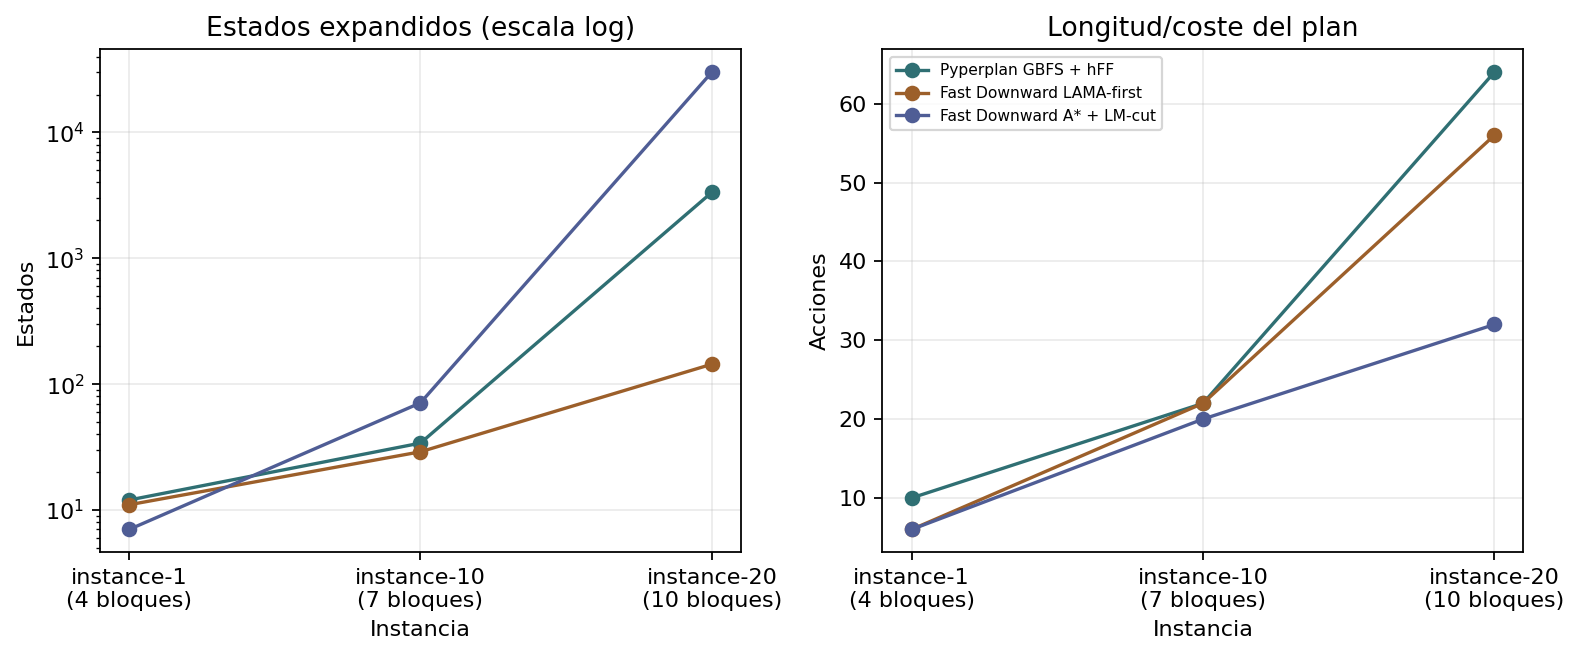

In [8]:
labels = [f"instance-{i}" for i in INSTANCES]
configs = []
for row in results:
    name = f"{row['planificador']}\n{row['configuracion']}"
    if name not in configs:
        configs.append(name)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=160)
colors = ["#2f6f73", "#9c5f2a", "#4f5d95"]
x_labels = [f"{label}\n({block_count(int(label.split('-')[1]))} bloques)" for label in labels]

for index, config in enumerate(configs):
    expanded = []
    costs = []
    for label in labels:
        row = next(item for item in results if item["instancia"] == label and f"{item['planificador']}\n{item['configuracion']}" == config)
        expanded.append(row.get("nodos_expandidos") or 0)
        costs.append(row.get("longitud_plan") or 0)
    axes[0].plot(x_labels, expanded, marker="o", color=colors[index], label=config.replace("\n", " "))
    axes[1].plot(x_labels, costs, marker="o", color=colors[index], label=config.replace("\n", " "))

axes[0].set_yscale("log")
axes[0].set_title("Estados expandidos (escala log)")
axes[0].set_ylabel("Estados")
axes[1].set_title("Longitud/coste del plan")
axes[1].set_ylabel("Acciones")
for axis in axes:
    axis.grid(True, alpha=0.25)
    axis.set_xlabel("Instancia")
axes[1].legend(fontsize=7, loc="upper left")
fig.tight_layout()
chart_path = ROOT / "comparativa_planificadores.png"
fig.savefig(chart_path, bbox_inches="tight")
print(f"Gráfica guardada en: {chart_path.name}")
plt.show()

## 9. Lectura de los resultados

La comparación permite separar dos criterios. Si se prioriza rapidez y un plan razonablemente bueno, Fast Downward con LAMA-first es la alternativa más equilibrada en estas instancias. Si se prioriza reducir la longitud/coste del plan, Fast Downward con A* + LM-cut consigue mejores planes, aunque expande muchos más estados. Pyperplan resuelve los tres problemas, pero sus planes son más largos en las instancias grandes.

In [9]:
summary = df[["instancia", "planificador", "configuracion", "nodos_expandidos", "tiempo_busqueda_s", "longitud_plan"]].copy()
summary.sort_values(["instancia", "longitud_plan", "nodos_expandidos"])

,instancia,planificador,configuracion,nodos_expandidos,tiempo_busqueda_s,longitud_plan
4,instance-1,Fast Downward,A* + LM-cut,7,0.000160,6
3,instance-1,Fast Downward,LAMA-first,11,0.000123,6
0,instance-1,Pyperplan,GBFS + hFF,12,0.001400,10
6,instance-10,Fast Downward,A* + LM-cut,71,0.002560,20
5,instance-10,Fast Downward,LAMA-first,29,0.000312,22
1,instance-10,Pyperplan,GBFS + hFF,34,0.012000,22
8,instance-20,Fast Downward,A* + LM-cut,30086,3.067291,32
7,instance-20,Fast Downward,LAMA-first,144,0.001303,56
2,instance-20,Pyperplan,GBFS + hFF,3341,3.000000,64
